Extrating Jupiter's data...


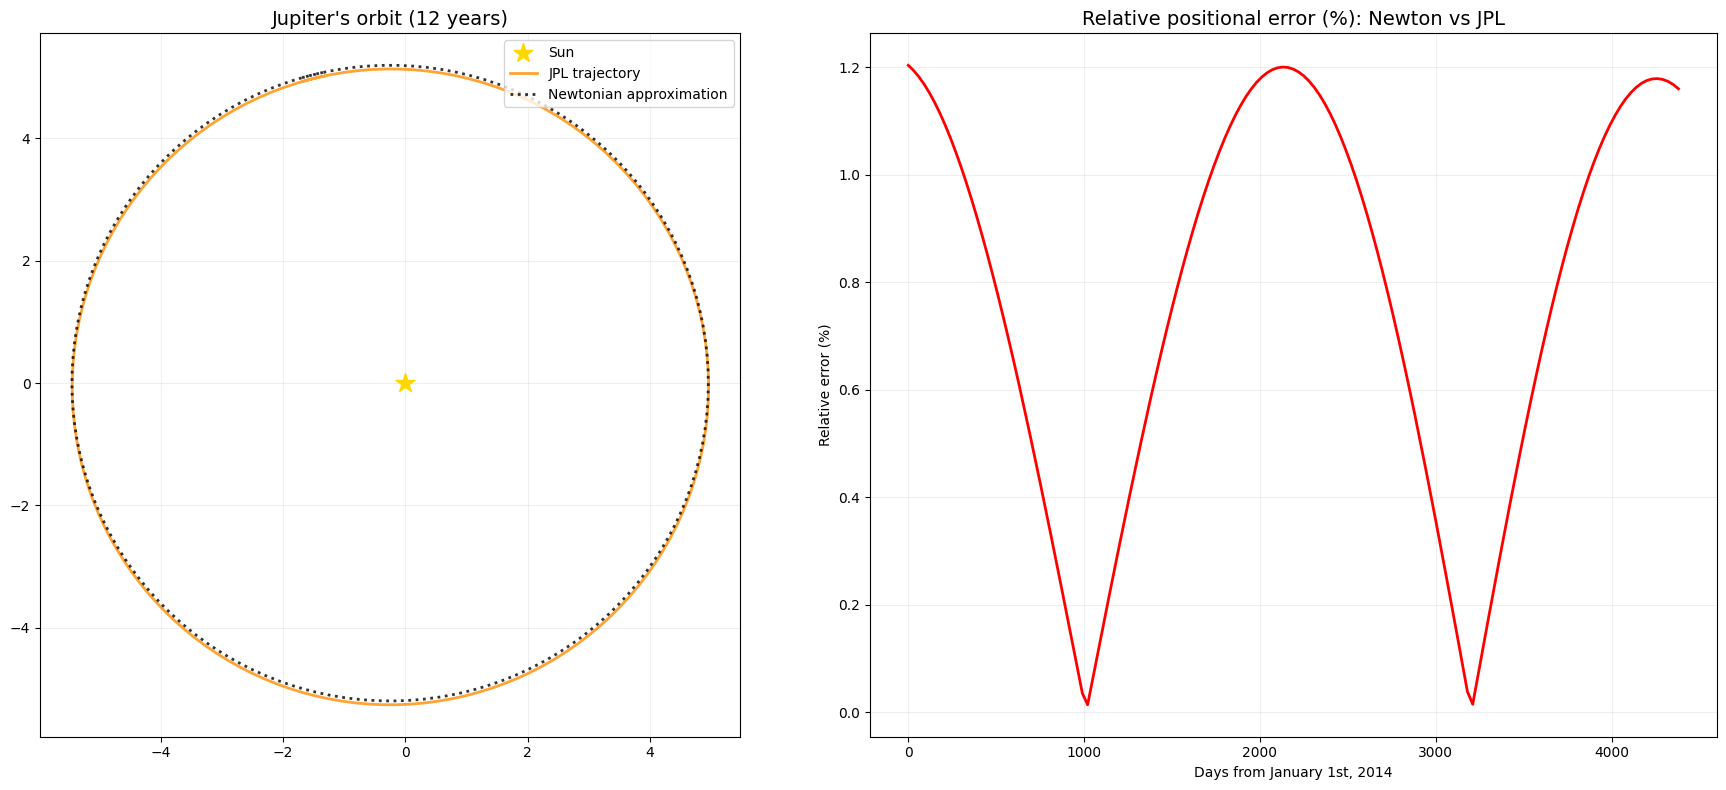

Average of the relative error: 0.77 %


In [3]:
!pip install -q astroquery #Install on Colab the library to load data from NASA
import numpy as np
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons #Import on Colab the library to load data from NASA

# --- Constants ---
AU_TO_KM = 1.496e+8
G_M_SUN = 0.0002959122
KM_S_CONVERSION = AU_TO_KM / 86400

# 1. Load 12 years of Jupiter's orbit, sampling the position once a month
print("Extrating Jupiter's data...")
epochs = {'start': '2014-01-01', 'stop': '2026-01-01', 'step': '30d'}
jup = Horizons(id='599', location='500@10', epochs=epochs).vectors()

# 2. Set up the Newtonian approximation fixing the parameters
p_jup = 5.19
e_jup= 0.048

# Read off coordinates in astronomial units (AU)
x_jup_jpl = jup['x']
y_jup_jpl = jup['y']
z_jup_jpl = jup['z']

# Compute theoretical prediction, extracting angles from JPL data
phi = np.arctan2(y_jup_jpl,x_jup_jpl)
r_jup = p_jup / (1 + e_jup * np.cos(phi))
x_jup = r_jup * np.cos(phi)
y_jup = r_jup * np.sin(phi)

# 3. Compute relative errors
x_diff = x_jup - x_jup_jpl
y_diff = y_jup - y_jup_jpl
rel_errors = 100*np.sqrt(x_diff**2 + y_diff**2)/np.sqrt(x_jup_jpl**2 + y_jup_jpl**2)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- LEFT: Orbit comparison ---
ax1.scatter(0, 0, color='gold', s=200, marker='*', label='Sun', zorder=5)

# Plotting JPL data (underneath)
ax1.plot(x_jup_jpl, y_jup_jpl, color='darkorange', lw=2, label='JPL trajectory', alpha=0.8)

# Plotting Newtonian model data
ax1.plot(x_jup, y_jup, 'k:', lw=2, label='Newtonian approximation', alpha=0.8)
ax2.set_xlabel("X (AU)")
ax2.set_ylabel("Y (AU)")
ax1.set_title("Jupiter's orbit (12 years)", fontsize=14)
ax1.set_aspect('equal')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.2)

# --- RIGHT: Relative error plot ---
days = np.arange(len(rel_errors)) * 30
ax2.plot(days, rel_errors, color='red', lw=2)
ax2.set_title("Relative positional error (%): Newton vs JPL", fontsize=14)
ax2.set_xlabel("Days from January 1st, 2014")
ax2.set_ylabel("Relative error (%)")
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Average of the relative error: {np.mean(rel_errors):,.2f} %")

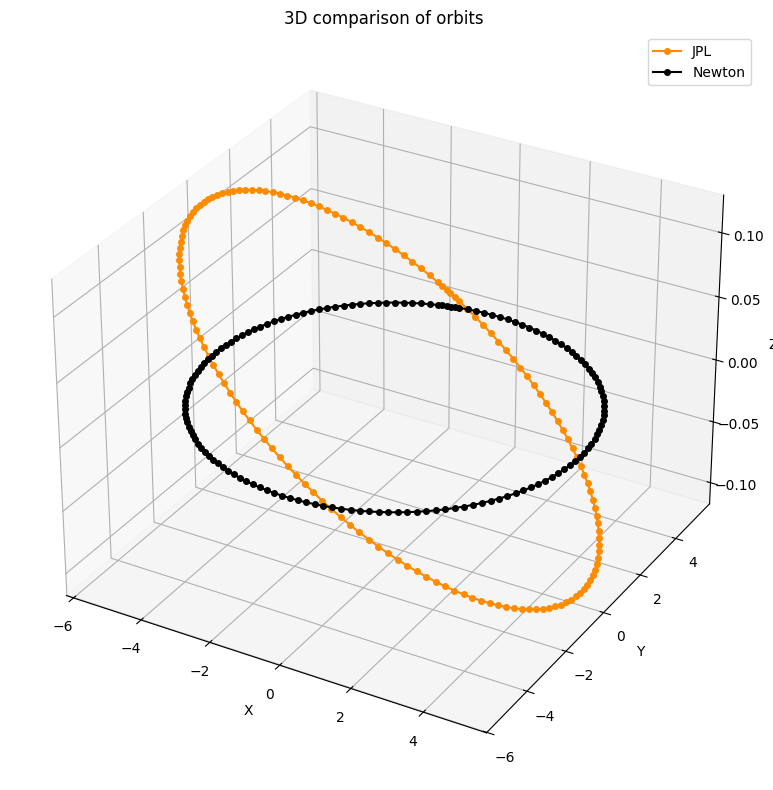

In [2]:
# Producing a 3D plot of Jupiter's orbit (to understand the periodicity of the error)
fig3d = plt.figure(figsize=(9, 8))
ax3d = fig3d.add_subplot(111, projection='3d')

ax3d.plot(x_jup_jpl, y_jup_jpl, z_jup_jpl, label='JPL',
        color='darkorange',
        linestyle='-',
        marker='o',
        markersize=4)
ax3d.plot(x_jup, y_jup, 0, label='Newton',
        color='black',
        linestyle='-',
        marker='o',
        markersize=4)

# Customizing the chart
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.set_title('3D comparison of orbits')
ax3d.legend()
plt.tight_layout()
plt.show()

Loading Borisov's data...


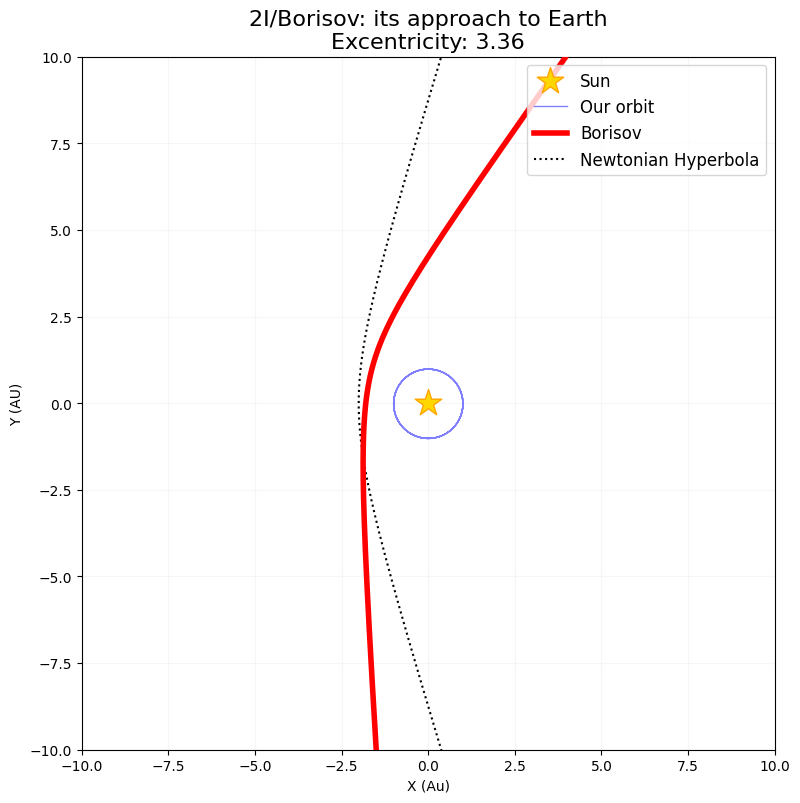

Distance convered by JPL data: 23.81 AU


In [5]:
# 1. Import all data available for the asteroid 2I-Borisov. From early 2018 until late 2022
# Load Earth's data
print("Loading Borisov's data...")
epochs = {'start': '2018-01-01', 'stop': '2022-01-01', 'step': '5d'}
borisov = Horizons(id='2I', location='500@10', epochs=epochs).vectors()
earth = Horizons(id='399', location='500@10', epochs=epochs).vectors()

# 2. Set up the Newtonian approximation for Jupiter
p_b = 8.74 # These quantities will change along the trajectory, but we keep them constant
e_b = 3.36

# 3. Visualization
fig, ax = plt.subplots(figsize=(9, 9))

# Sun
ax.scatter(0, 0, color='gold', s=400, marker='*', label='Sun', edgecolors='orange', zorder=10)

# Earth
ax.plot(earth['x'], earth['y'], color='blue', lw=1, alpha=0.5, label='Our orbit')

# Borisov's trajectory (from JPL)
ax.plot(borisov['x'], borisov['y'], color='red', lw=4, label='Borisov', zorder=5)

# 4. Newtonian prediction
# Max. angle to avoid divergence given by arccos(-1/e)
limit_theta_hyp = np.arccos(-1/e_b)

# The range of theta values to consider is
theta_hyp = np.linspace(-limit_theta_hyp + 0.01, limit_theta_hyp - 0.01, 1000)
r_hyp = p_b / (1 + e_b * np.cos(theta_hyp))
x_hyp = -r_hyp * np.cos(theta_hyp)
y_hyp = r_hyp * np.sin(theta_hyp)

# Plotting Newtonian estimation
ax.plot(x_hyp, y_hyp, color='black', ls=':', lw=1.5, label='Newtonian Hyperbola')

# Plotting and formatting
title_str = (r"2I/Borisov: its approach to Earth" + "\n" +
             fr"Excentricity: {e_b:.2f}")
ax.set_title(title_str, fontsize=16)

ax.set_xlabel("X (Au)"), ax.set_ylabel("Y (AU)")
ax.set_xlim(-10, 10), ax.set_ylim(-10, 10) # Deep solar system view
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.1)

plt.show()

print(f"Distance convered by JPL data: {np.linalg.norm(np.array([borisov['x'][-1]-borisov['x'][0], borisov['y'][-1]-borisov['y'][0]])):.2f} AU")